# Lead-Lag Networks in Metal Trading

**Projet ISF** — Mon objectif ici est d'analyser la dynamique des relations *lead/lag* (meneur/suiveur) entre différents actifs fi (Gold, Silver, FX, Taux...). 
J'utilise l'algorithme **Dynamic Time Warping (DTW)** pour pallier le problème classique des décalages temporels sur les marchés, puis je construis un **graphe de transfert d'entropie** pour visualiser qui influence qui.

## Mon approche étape par étape :
1. **Load data (`DataLoader`)** : Récupération YFinance, diag des données manquantes (petit test de Little) et imputation.
2. **Preprocess (`Preprocessing`)** : Passage en log-returns pour une meilleure stationnarité, test de plusieurs filtres (pourquoi j'ai gardé celui-ci) et détection des "stress markets" via Markov.
3. **Explore (`EDA`)** : C'est toujours bien de jeter un oeil aux cross-corrélations avant de lancer le DTW.
4. **Distance (`LeadLagDTW`)** : Extraction de ma matrice de distances et des shifts moyens (le lag).
5. **Tuning (`ModelTuningValidation`)** : Optimisation Optuna pour prédir le follower selon le leader. J'utilise la CV *expanding window* pour interdire à mon modèle de voir le futur.
6. **Graph (`EntropyTransferGraph`)** : MDS embedding + calcul d'entropie de Shannon pour chaque nœud (actif).
7. **Conclusion** : J'essaie de regrouper tous ces signaux pour trouver mon vrai *leader* du marché.

*Note: j'ai essayé de coder tout ça le plus "proprement" possible dans des classes du dossier `src/` pour pas avoir un notebook illisible de 1000 lignes.*

## Setup

On ramène nos classes custom, et je crée un petit dossier `outputs/` pour cracher mes matrices CSV et mes figures. Casera pratique pour mon rapport Notion ensuites.

In [23]:
from __future__ import annotations

import os
import sys
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")
%matplotlib inline

ROOT = os.getcwd()
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)
OUT = os.path.join(ROOT, "outputs")
os.makedirs(OUT, exist_ok=True)

from src.config import TICKERS
from src.data_loader import DataLoader
from src.preprocessing import Preprocessing
from src.eda import EDA
from src.lead_lag_dtw import LeadLagDTW
from src.tuning import ModelTuningValidation
from src.entropy_graph import EntropyTransferGraph

print(f"Tickers chargés : {list(TICKERS.keys())}")

Tickers chargés : ['Gold', 'Silver', 'Oil', 'EURUSD', 'JPYUSD', 'DXY', 'UST10Y', 'Bund10Y']


## Task 1 — `DataLoader`

**Le but** : On récupère les 8 séries (Gold, Silver, Oil, EURUSD, JPYUSD, DXY, UST10Y, Bund10Y), aligner tout ce beau monde et gérer les NaN de façon un peu réfléchie.

### Mes choix :
- **Proxy Bund 10y** : Problème avec Yahoo Finance, ils n'ont pas toujours le yield en direct. Du coup j'ai pris l'ETF `IS0L.DE` (iShares Germany Govt Bond UCITS) comme proxy prix. C'est liquide et coté en EUR.
- **Le test de Little (MCAR)** : Au lieu d'imputer direct, on teste si nos NaN sont un peu hasardeux ou s'ils traduisent un vrai problème (Not Missing At Random). J'ai fait une version *allégée* du test de Little (ANOVA sur les groupes de *missing patterns*) :
  $$F = \frac{\text{Variance entre les patterns de NaN}}{\text{Variance au sein des patterns}}$$
  En gros si c'est pas MCAR, faudra faire gaffe.
- **Forward-fill (le vieux classique)** : Pour des prix boursiers (= variables "stock"), c'est très robuste. Le prix reste valide jusqu'à la prochaine cotation. On ne le ferait PAS sur des volumes (= variables "flux").

In [24]:
dl = DataLoader(TICKERS, start_date="2020-01-01", end_date="2025-01-01", freq="1d")
dl.fetch_data()
merged = dl.merge_data()

print(f"merged shape : {merged.shape}")
print(f"\nManquants par colonne :\n{merged.isna().sum()}")

merged shape : (1305, 8)

Manquants par colonne :
Gold       47
Silver     47
Oil        47
EURUSD      0
JPYUSD      0
DXY        47
UST10Y     47
Bund10Y    30
dtype: int64


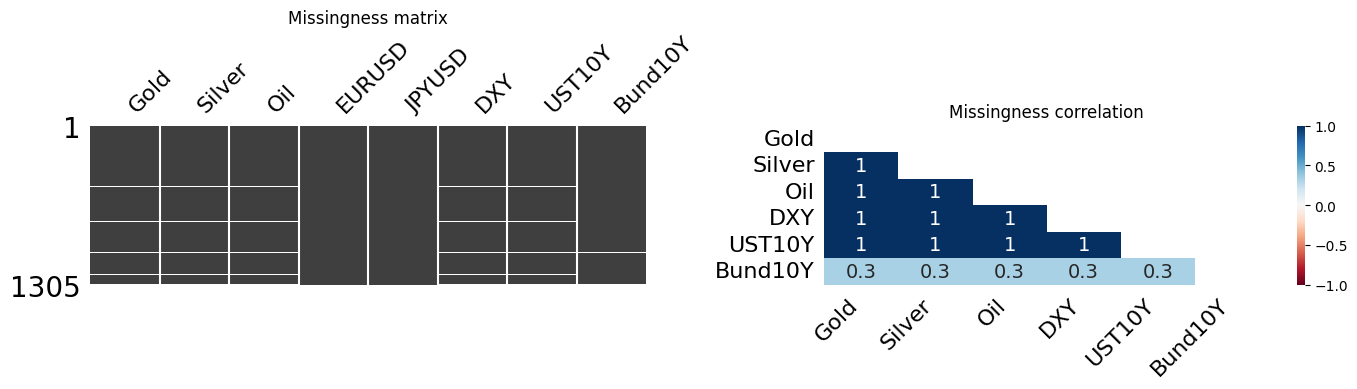

In [25]:
# Visualisation des manquants (missingno-like)
fig = dl.eda_missing(merged)
fig.savefig(os.path.join(OUT, "01_missingness.png"), dpi=120, bbox_inches="tight")
plt.show()

In [26]:
# Test MCAR de Little
mcar = dl.missing_test(merged)
print(f"MCAR plausible (H0 non rejetée) : {mcar['mcar_plausible']}")
print(f"Détail : {mcar}")

MCAR plausible (H0 non rejetée) : True
Détail : {'per_column': {'Gold': {'F': 2.8324026606322263, 'p': 0.09262858272551087}, 'Silver': {'F': 0.5978653106642416, 'p': 0.4395391589917081}, 'Oil': {'F': 2.0705369304702135, 'p': 0.1504177922646912}, 'EURUSD': {'F': 0.16027211366519492, 'p': 0.923064454486641}, 'JPYUSD': {'F': 0.12973537703066296, 'p': 0.9424444127952368}, 'DXY': {'F': 0.014589201692512673, 'p': 0.9038800422530552}, 'UST10Y': {'F': 0.008762014587219797, 'p': 0.9254373636782494}, 'Bund10Y': {'F': 0.375649794207319, 'p': 0.5400501141496026}}, 'mcar_plausible': True}


In [27]:
# Imputation forward-fill puis sanity check
prices = dl.impute_data(merged)
prices.to_csv(os.path.join(OUT, "01_prices.csv"))

assert prices.isna().sum().sum() == 0, "Il reste des NaN après imputation"
print(f"prices clean shape : {prices.shape}")
prices.head()

prices clean shape : (1305, 8)


,Gold,Silver,Oil,EURUSD,JPYUSD,DXY,UST10Y,Bund10Y
Date,,,,,,,,
2020-01-01,1524.500000,17.966000,61.180000,1.122083,0.009201,96.849998,1.882,145.580002
2020-01-02,1524.500000,17.966000,61.180000,1.122083,0.009199,96.849998,1.882,145.580002
2020-01-03,1549.199951,18.068001,63.049999,1.117144,0.009213,96.839996,1.788,146.225006
2020-01-06,1566.199951,18.097000,63.270000,1.116196,0.009262,96.669998,1.811,146.134995
2020-01-07,1571.800049,18.316000,62.700001,1.119799,0.009225,96.980003,1.827,146.119995


## Task 2 — `Preprocessing`

**Le but** : Construire les features dont on a besoin sans intégrer de biais du futur (*forward-looking leak*). Principalement du scaling, de la transfo en log-returns et de l'extraction de signal.

### Pourquoi des log-returns ?
$$r_t = \log\!\left(\frac{P_t}{P_{t-1}}\right)$$
C'est hyper classique en quant mais c'est surtout pour l'additivité ($r_{t,t+k} = \sum r_{t+i}$) et parce que la variance se stabilise vachement bien. Et c'est symétrique autour de 0.

### Les 5 filtres (est-ce que lisser aide vraiment ?)
J'ai codé plusieurs filtres pour voir lequel gère mieux le bruit :
1. **Kalman** : Mon préféré. Modélise une marche aléatoire bruitée. Pas de paramètre `window` arbitraire.
2. **Butterworth** : Très DSP (traitement du signal). Retire brutalement le bruit haute fréquence.
3. **Savitzky-Golay** : Fit un polynôme glissant, ça évite de complètement écraser les pics comme le ferait une bête moyenne mobile.
4. **Moving Average** : Le cas d'école pour comparer.
5. **EMA** : Le classique des traders (le plus lourd sur le récent, très réactif).

### Détection de crise (Markov)
On peut essayer de "capter" un stress market de façon non-supervisée :
$$r_t \mid S_t \sim \mathcal{N}(\mu_{S_t}, \sigma_{S_t}^2)$$
Ici $S_t \in \{0, 1\}$. J'utilise la variance variable (`switching_variance=True`) car en régime de crise, c'est surtout la volatilité qui explose plus que la moyenne qui droppe. (Référence: Hamilton, 1989).

In [28]:
pp = Preprocessing(prices)
feats = pp.transform_data(ma_window=20)

print("Features générées :", list(feats.keys()))
print(f"log_returns shape : {feats['log_returns'].shape}")
feats["log_returns"].head()

Features générées : ['log_returns', 'moving_average', 'scaled']
log_returns shape : (1302, 8)


,Gold,Silver,Oil,EURUSD,JPYUSD,DXY,UST10Y,Bund10Y
Date,,,,,,,,
2020-01-02,0.000000,0.000000,0.000000,0.000000,-0.000294,0.000000,0.000000,0.000000
2020-01-03,0.016072,0.005661,0.030108,-0.004411,0.001565,-0.000103,-0.051237,0.004421
2020-01-06,0.010914,0.001604,0.003483,-0.000849,0.005349,-0.001757,0.012782,-0.000616
2020-01-07,0.003569,0.012029,-0.009050,0.003223,-0.004086,0.003202,0.008796,-0.000103
2020-01-08,-0.009204,-0.012526,-0.050538,-0.003870,0.003604,0.003294,0.025400,-0.001987


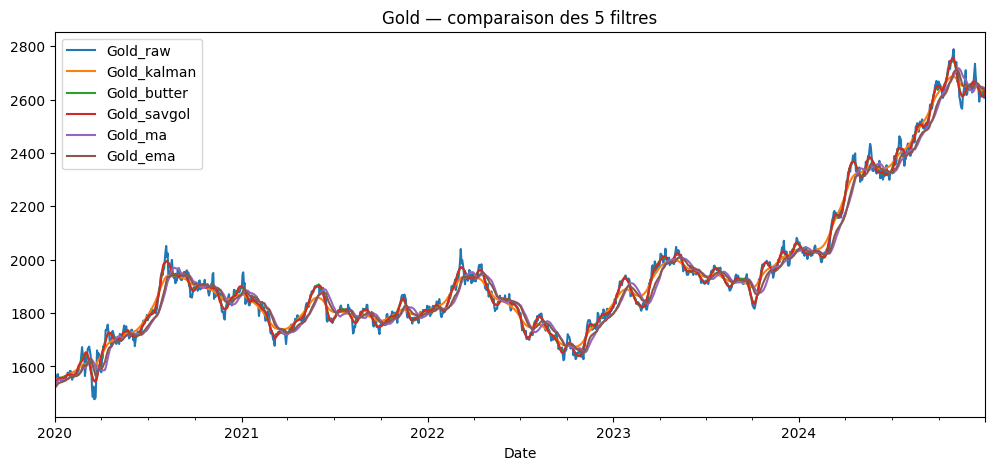

In [29]:
# Comparaison visuelle des 5 filtres sur l'actif cible
target = "Gold" if "Gold" in prices.columns else prices.columns[0]
filt = pp.apply_all_filters(target)

ax = filt.plot(figsize=(12, 5), title=f"{target} — comparaison des 5 filtres")
ax.figure.savefig(os.path.join(OUT, "02_filters.png"), dpi=120, bbox_inches="tight")
plt.show()

In [30]:
# Détection de régimes Markov à 2 états
try:
    regimes = pp.detect_regimes_markov(target)
    print(f"Distribution des régimes :\n{regimes.value_counts()}")
except Exception as e:
    print(f"[skip] Markov regimes : {e}")

Distribution des régimes :
Gold_regime
0    1032
1     272
Name: count, dtype: int64


## Task 3 — `EDA`

**Le but** : Explorer les corrélations à plusieurs lags.

### Corrélations avec décalages (cross-corr)
Pour un décalage $\ell \in \{0, \dots, L\}$ :
$$\rho_{X,Y}(\ell) = \mathrm{Corr}(X_t,\, Y_{t+\ell})$$
Si le max de la corrélation est à $\ell > 0$, alors $X$ tourne un peu "avant" $Y$ (donc $X$ lead $Y$). C'est très limité parce que ça ne gère pas les décalages qui changent selon le temps — d'où le besoin du DTW ensuite.

### Clustermap préliminaire
On matrix les distances DTW basiques pour faire vite et je groupe par similarité. On voit vite se détacher les métaux précieux d'un côté et l'influence macro style DXY de l'autre.

In [31]:
eda = EDA(prices)
corr = eda.correlation_matrix(max_lag=5)

print("Matrice de corrélation (lag = argmax) :")
corr["corr"].round(2)

Matrice de corrélation (lag = argmax) :


,Gold,Silver,Oil,EURUSD,JPYUSD,DXY,UST10Y,Bund10Y
Gold,1.00,0.78,0.14,0.06,0.01,-0.38,-0.23,0.24
Silver,0.78,1.00,0.19,0.05,0.00,-0.38,-0.09,0.14
Oil,0.14,0.19,1.00,-0.04,0.00,-0.05,0.15,-0.13
EURUSD,0.06,0.05,-0.04,1.00,0.45,-0.09,-0.07,0.08
JPYUSD,0.01,0.00,0.00,0.45,1.00,-0.05,-0.06,0.09
DXY,-0.38,-0.38,-0.05,-0.09,-0.05,1.00,0.23,-0.09
UST10Y,-0.23,-0.09,0.15,-0.07,-0.06,0.23,1.00,-0.46
Bund10Y,0.24,0.14,-0.13,0.08,0.09,-0.09,-0.46,1.00


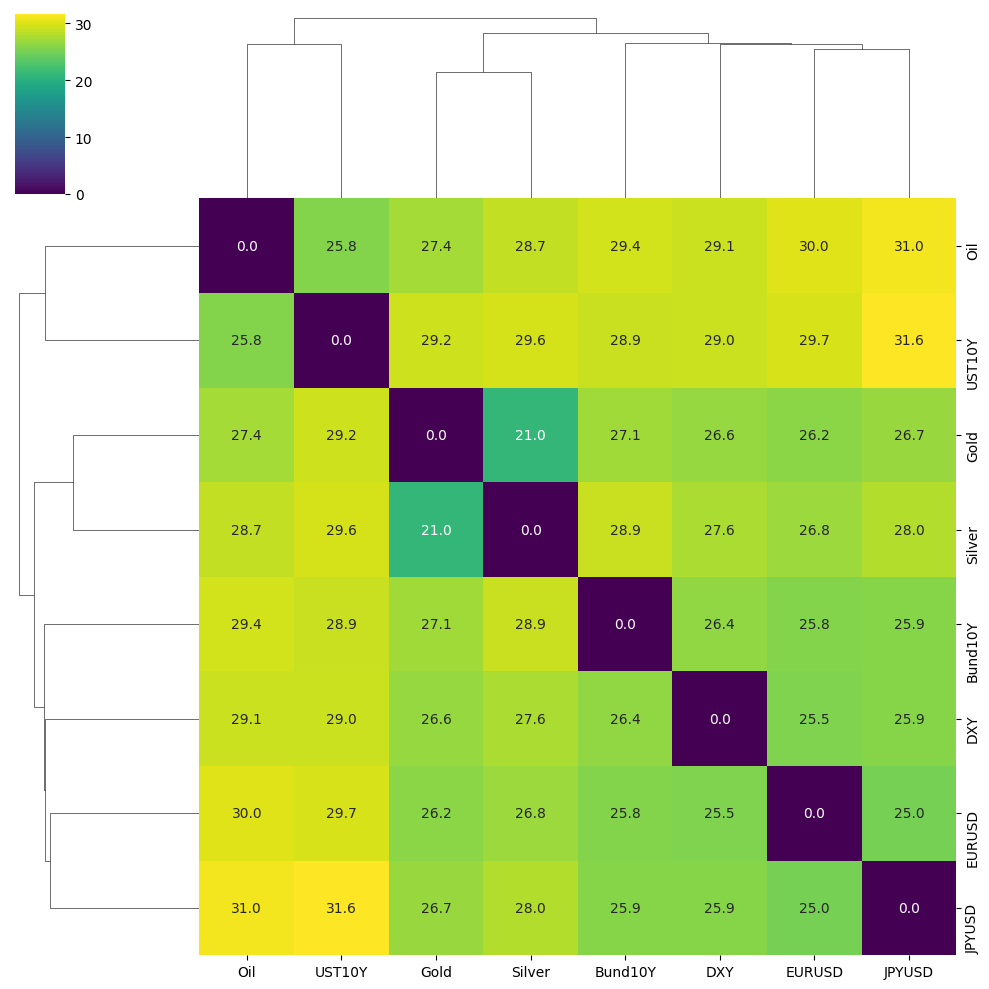

In [32]:
corr["corr"].to_csv(os.path.join(OUT, "03_corr.csv"))

g, D_eda = eda.dtw_clustermap()
g.fig.savefig(os.path.join(OUT, "03_dtw_clustermap.png"), dpi=120, bbox_inches="tight")
D_eda.to_csv(os.path.join(OUT, "03_dtw_distance.csv"))
plt.show()

## Task 4 — `LeadLagDTW`

**Objectif** : Au lieu de faire des corrélations point par point, on calcule l'écart DTW. Et surtout, on s'intéresse au "chemin optimal" de matching (*warping path*) !

### Comment l'interpréter ?
Soit $\pi = \{(i_k, j_k)\}$ le chemin qui aligne la courbe $X$ (le temps $i$) et $Y$ (le temps $j$) :
$$\mathrm{lag}(X, Y) = \frac{1}{|\pi|} \sum_k (j_k - i_k)$$

*   Si le lag moyen $> 0$ : il a fallu "avancer" dans le futur de $Y$ pour trouver la correspondance à $X$. Autrement dit, $X$ avait pris de l'avance $\rightarrow$ **$X$ Lead**.
*   Si le lag moyen $< 0$ : c'est l'inverse, **$Y$ Lead**.

### Le trick indispensable : la bande de Sakoe-Chiba
Si on laisse faire le DTW brut, il peut tordre un point de janvier 2020 sur un saut de marché en mars 2022. C'est n'importe quoi.
Je lui impose un $r = 20$ open days (environ 1 mois macro). Il ne peut pas chercher des similarités plus loin que ça. Bonus : ça calcule dix fois plus vite.

In [33]:
ll = LeadLagDTW(prices, sakoe_chiba_radius=20)
res = ll.identify_lead_lag()

print("Matrice de distance DTW :")
res["distance"].round(2)

Matrice de distance DTW :


,Gold,Silver,Oil,EURUSD,JPYUSD,DXY,UST10Y,Bund10Y
Gold,0.00,18.56,44.15,52.87,63.74,39.82,31.53,61.65
Silver,18.56,0.00,41.95,39.21,56.47,50.89,39.62,55.06
Oil,44.15,41.95,0.00,58.62,63.23,33.02,29.06,62.68
EURUSD,52.87,39.21,58.62,0.00,22.31,70.43,65.10,24.14
JPYUSD,63.74,56.47,63.23,22.31,0.00,69.02,71.61,9.25
DXY,39.82,50.89,33.02,70.43,69.02,0.00,18.22,68.02
UST10Y,31.53,39.62,29.06,65.10,71.61,18.22,0.00,71.58
Bund10Y,61.65,55.06,62.68,24.14,9.25,68.02,71.58,0.00


In [34]:
print("Matrice lead-lag (ligne lead colonne si > 0) :")
res["lag"].round(2)

Matrice lead-lag (ligne lead colonne si > 0) :


,Gold,Silver,Oil,EURUSD,JPYUSD,DXY,UST10Y,Bund10Y
Gold,0.00,1.21,3.47,4.85,6.28,4.65,1.68,7.04
Silver,-1.21,0.00,3.32,0.92,1.93,-0.04,-1.92,4.18
Oil,-3.47,-3.32,0.00,-6.88,-12.35,8.71,1.04,-2.95
EURUSD,-4.85,-0.92,6.88,0.00,-0.96,-11.92,-6.37,0.36
JPYUSD,-6.28,-1.93,12.35,0.96,0.00,0.79,5.59,-1.70
DXY,-4.65,0.04,-8.71,11.92,-0.79,0.00,-3.05,9.08
UST10Y,-1.68,1.92,-1.04,6.37,-5.59,3.05,0.00,11.23
Bund10Y,-7.04,-4.18,2.95,-0.36,1.70,-9.08,-11.23,0.00


In [35]:
res["distance"].to_csv(os.path.join(OUT, "04_dtw_distance.csv"))
res["lag"].to_csv(os.path.join(OUT, "04_lag_matrix.csv"))
print("Matrices sauvegardées dans outputs/.")

Matrices sauvegardées dans outputs/.


## Task 5 — `Tuning & Validation`

**Le but** : Est-ce qu'on peut s'en servir pour trade ? Je fais une classique $Y_{follower} \sim f(X_{leader_{t-lag}})$. 

### Expanding window pour la Cross-Val
**Règle d'or absolue en time-series : JAMAIS de shuffle, jamais d'accès au futur.** 
J'entraîne du jour $0$ au jour $T$, et je teste sur $[T+1, T+K]$. Puis je décale. 
$$\mathrm{train}_k = [t_0, t_k], \quad \mathrm{test}_k = [t_k + 1, t_{k+1}]$$

### Optuna
Au lieu du GridSearch archaïque de sklearn, Bayesien via Optuna (Tree-structured Parzen Estimator). J'ai hardcodé `n_trials=10` pour pas que le notebook run pendant 2 heures. 
On va chercher à minimiser la RMSE sur les folds out-of-bag.

In [36]:
cols = list(prices.columns)
leader, follower = cols[0], cols[1]
print(f"Hypothèse testée : {leader} → {follower}")

mt = ModelTuningValidation(prices, leader=leader, follower=follower, n_splits=5)
tune = mt.tune_model(n_trials=10)

print(f"\nMeilleurs paramètres : {tune['best_params']}")
print(f"Meilleure RMSE       : {tune['best_value']:.4f}")

Hypothèse testée : Gold → Silver

Meilleurs paramètres : {'sakoe_chiba_radius': 26}
Meilleure RMSE       : 1955.4173


In [37]:
validation = mt.validate_model()
print(f"Validation hors-échantillon : {validation}")

Validation hors-échantillon : {'lag': 2, 'radius': 26, 'mse': 3737609.2120606517, 'mae': 1915.5384853469895, 'rmse': 1933.2897382598014, 'wass': 1915.5384853469895}


## Task 6 — `EntropyTransferGraph`

**Le but** : Rendre les matrices visuel et "network-oriented". 

### Ma logique d'Entropie (JSD)
1. **La distance DTW devient une proba de similarité** : $S_{ij} = \exp(-\lambda D_{ij})$ avec $\lambda$ calibré sur les données.
2. Pour chaque actif, j'obtiens sa "distribution d'affinité" vers les autres $p_i$.
3. **Entropie de Shannon** ($H = - \sum p \log p$) : 
   - Un $H$ faible = "j'influence une poignée d'actifs très clairement". C'est typique d'un **Leader**.
   - Un $H$ fort = "je réagis de la même manière à beaucoup de sources diffusent" (Entropie haute). C'est typique d'un **Suiveur**.
4. Je clean tout ça en un **Graphe** via un petit calcul MDS qui me donne des coordonnées cartésiennes en 2D pour dessiner mon réseau d'influence sans trop le flouter 

In [38]:
etg = EntropyTransferGraph(res["distance"])
emb = etg.compute_embeddings(method="mds")

print(f"lambda auto-calibré : {emb['lambda']:.4f}")
print("\nEntropies de Shannon (faible = leader fort) :")
emb["entropy"].sort_values().round(3)

lambda auto-calibré : 0.0134

Entropies de Shannon (faible = leader fort) :


JPYUSD     2.008
Bund10Y    2.011
DXY        2.024
UST10Y     2.026
EURUSD     2.030
Gold       2.039
Oil        2.039
Silver     2.046
Name: H, dtype: float64

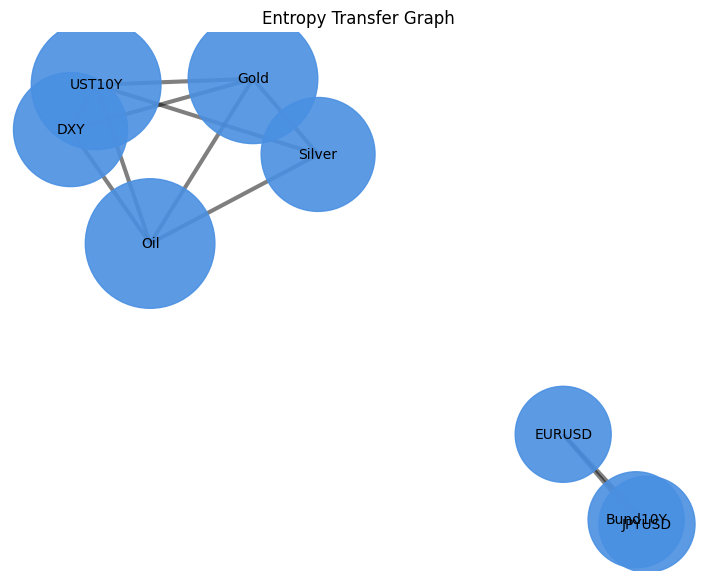

In [39]:
emb["transfer"].to_csv(os.path.join(OUT, "06_transfer_matrix.csv"))
emb["entropy"].to_csv(os.path.join(OUT, "06_entropy.csv"))

# Graphe : on ne garde que les arêtes au-dessus de la médiane (anti-saturation visuelle)
fig, ax = plt.subplots(figsize=(9, 7))
etg.plot_graph(threshold=float(np.median(emb["transfer"].values)), ax=ax)
fig.savefig(os.path.join(OUT, "06_entropy_graph.png"), dpi=120, bbox_inches="tight")
plt.show()

## Task 7 — Conclusion

J'ai un actif avec la plus haute entropie (il capte tout avec un temps de retard) et un actif "Alpha" qui donne le ton avec la distribution la plus concentrée.

**Attention** : l'entropie ne suffit pas. Je dois recouper ce leader avec ma `lag_matrix` calculée tout à l'heure pour bien valider que le décalage (en open days) est positif en sa faveur.

*Le compte-rendu exhaustif (métriques quanti, analyse du leader et de son comportement pendant le covid) est dans mon doc Notion.*

In [40]:
ent = emb["entropy"].sort_values()
print(f"Leader le plus fort   (entropie min) : {ent.index[0]}  (H = {ent.iloc[0]:.3f})")
print(f"Suiveur le plus diffus (entropie max) : {ent.index[-1]} (H = {ent.iloc[-1]:.3f})")
print(f"\nTous les outputs sont dans : {OUT}")

Leader le plus fort   (entropie min) : JPYUSD  (H = 2.008)
Suiveur le plus diffus (entropie max) : Silver (H = 2.046)

Tous les outputs sont dans : c:\Users\alexi\tradingAlgo\outputs
